# Full-scale re-clustering — 1.47M → 677k → 3,350 clusters

**What we did.** Ran the stratified `(sector, sub_code)` Leiden pipeline on the full 1.47M policy corpus:

1. Classified all 1,465,440 policies with **Gemma 4 12B on one H100** (`v1-expert-5class-10sub` prompt, 10 few-shot from expert gold).
2. Filtered to `sufficiency + ambiguous` → **676,876 policies survived** (46%).
3. Ran Leiden per `(sector, sub_code)` cell with size-adaptive resolution.
4. Judged **353 randomly-sampled new clusters** via the DeepSeek V4 intrusion task (few-shot calibrated).

**Baselines to beat.**
- Old clustering (`clusters_2026-03-18`, unfiltered): **73.5%** judge accuracy on 433 clusters.
- 100k-subset stratified re-clustering (iteration 3): **77.9%** judge accuracy on 253 clusters.

**Cost of this iteration.** ~$32 H100 rental + ~$0.50 judge API. Full pipeline instrumented with codecarbon; totals in section 8.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

ROOT = Path("../../runs/full_recluster")

sectors = ["BUILDING", "ENERGY", "FOOD", "INDUSTRY", "LOGISTICS",
           "MACROECONOMIC", "MATERIALS", "MOBILITY", "NATURE", "SOCIAL", "URBAN"]
frames = []
for s in sectors:
    frames.append(pd.read_parquet(ROOT / f"reclustered/{s}_reclustered_2026-06-13.parquet"))
df = pd.concat(frames, ignore_index=True)
print(f"loaded {len(df):,} rows, {df['new_cluster_uid'].nunique():,} new clusters")

emissions = pd.read_csv(ROOT / "emissions.csv")
print(f"emissions rows: {len(emissions):,}")

loaded 676,876 rows, 3,350 new clusters
emissions rows: 20


## 1. Full-corpus picture — 677k policies, 3,350 clusters

SOCIAL alone accounts for 39% of the surviving pool (263k policies, 556 clusters). Big-sector dominance mirrors the 100k iteration but at scale — one out of every three surviving sufficiency-related policies came from the SOCIAL sector.

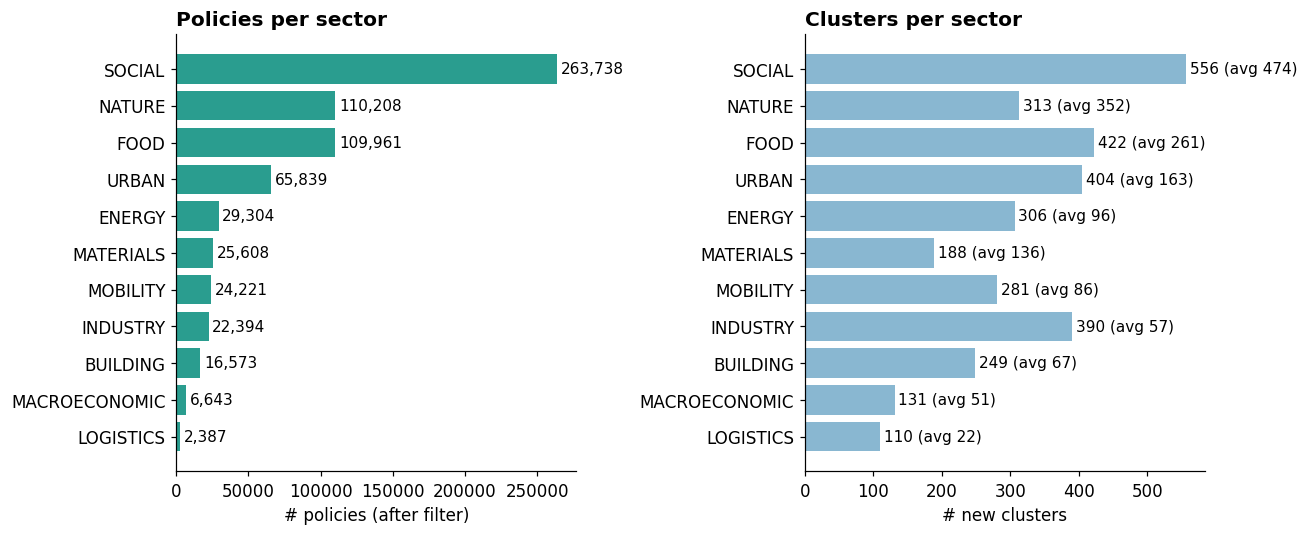

In [2]:
per_sector = df.groupby("sector").agg(
    n_policies=("policy_text", "size"),
    n_clusters=("new_cluster_uid", "nunique"),
).sort_values("n_policies", ascending=False)
per_sector["mean_size"] = per_sector["n_policies"] / per_sector["n_clusters"]

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].barh(per_sector.index, per_sector["n_policies"], color="#2a9d8f")
ax[0].invert_yaxis()
ax[0].set_xlabel("# policies (after filter)")
ax[0].set_title("Policies per sector", loc="left", fontweight="bold")
for i, (s, r) in enumerate(per_sector.iterrows()):
    ax[0].text(r["n_policies"] + per_sector["n_policies"].max() * 0.01, i,
               f"{int(r['n_policies']):,}", va="center", fontsize=10)

ax[1].barh(per_sector.index, per_sector["n_clusters"], color="#89b7d1")
ax[1].invert_yaxis()
ax[1].set_xlabel("# new clusters")
ax[1].set_title("Clusters per sector", loc="left", fontweight="bold")
for i, (s, r) in enumerate(per_sector.iterrows()):
    ax[1].text(r["n_clusters"] + per_sector["n_clusters"].max() * 0.01, i,
               f"{int(r['n_clusters'])} (avg {r['mean_size']:.0f})",
               va="center", fontsize=10)
plt.tight_layout()
plt.show()

## 2. Cluster size distribution — where the resolution parameter landed

The right tail is much heavier than in the 100k iteration. Median cluster size jumped from 3 (100k) to something larger here — sensible: 20× more data, Leiden at the same resolution parameter makes bigger clusters.

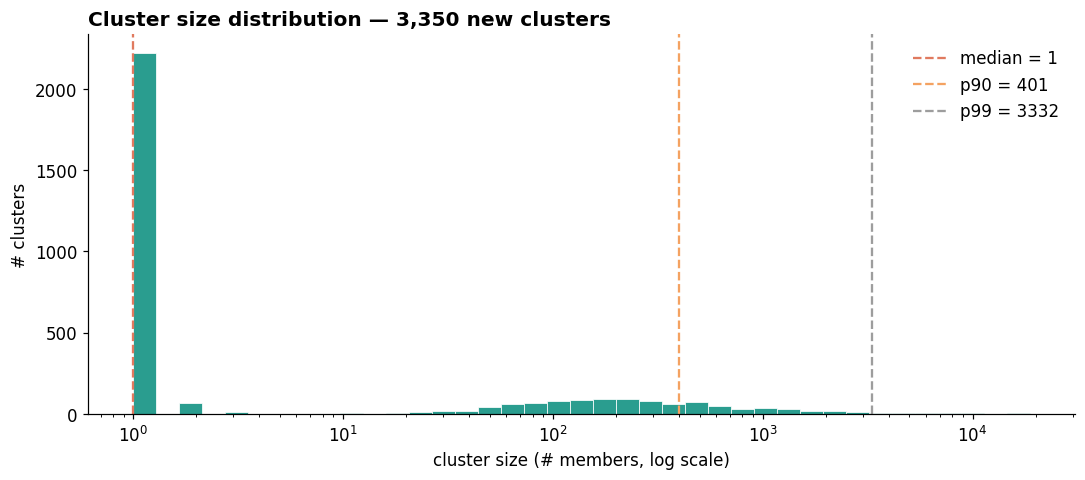

Cluster size summary:
count     3350.0
mean       202.1
std        927.4
min          1.0
25%          1.0
50%          1.0
75%         84.0
max      18746.0


In [3]:
sizes = df.groupby(["sector", "new_cluster_uid"]).size().rename("n_members").reset_index()

fig, ax = plt.subplots(figsize=(10, 4.5))
bins = np.logspace(0, np.log10(sizes["n_members"].max() + 1), 40)
ax.hist(sizes["n_members"], bins=bins, color="#2a9d8f", edgecolor="white", linewidth=0.5)
ax.set_xscale("log")
ax.set_xlabel("cluster size (# members, log scale)")
ax.set_ylabel("# clusters")
median = int(sizes["n_members"].median())
p90 = int(sizes["n_members"].quantile(0.9))
p99 = int(sizes["n_members"].quantile(0.99))
ax.axvline(median, color="#e07a5f", linestyle="--", label=f"median = {median}")
ax.axvline(p90, color="#f4a261", linestyle="--", label=f"p90 = {p90}")
ax.axvline(p99, color="#9d9d9d", linestyle="--", label=f"p99 = {p99}")
ax.set_title("Cluster size distribution — 3,350 new clusters", loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

print("Cluster size summary:")
print(sizes["n_members"].describe().round(1).to_string())

## 3. Sub-code composition — the mechanism map

Two sub-codes dominate the sufficiency-related literature:

- **Public provisioning (9)** — collective/universal provision of needs at low throughput. 290k policies.
- **Caps, limits & bans (1)** — regulatory ceilings. 173k policies.

Together they're 68% of all sufficiency policies. The other eight sub-codes combined are the remaining 32%. Sub-code 0 (involuntary demand cut) is tiny — only 2.8k policies, mostly COVID/rationing scholarship.

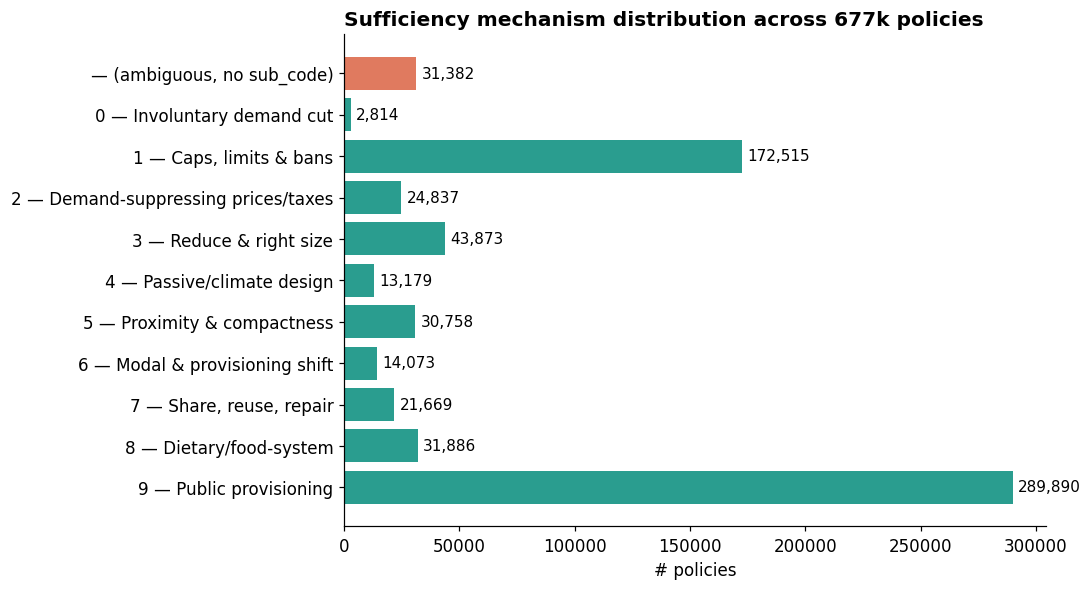

Share of policies per sub-code:
  — (ambiguous, no sub_code)                 31,382  (4.6%)
  0 — Involuntary demand cut                  2,814  (0.4%)
  1 — Caps, limits & bans                   172,515  (25.5%)
  2 — Demand-suppressing prices/taxes        24,837  (3.7%)
  3 — Reduce & right size                    43,873  (6.5%)
  4 — Passive/climate design                 13,179  (1.9%)
  5 — Proximity & compactness                30,758  (4.5%)
  6 — Modal & provisioning shift             14,073  (2.1%)
  7 — Share, reuse, repair                   21,669  (3.2%)
  8 — Dietary/food-system                    31,886  (4.7%)
  9 — Public provisioning                   289,890  (42.8%)


In [4]:
SUB_LABELS = {
    -1: "— (ambiguous, no sub_code)",
    0: "0 — Involuntary demand cut",
    1: "1 — Caps, limits & bans",
    2: "2 — Demand-suppressing prices/taxes",
    3: "3 — Reduce & right size",
    4: "4 — Passive/climate design",
    5: "5 — Proximity & compactness",
    6: "6 — Modal & provisioning shift",
    7: "7 — Share, reuse, repair",
    8: "8 — Dietary/food-system",
    9: "9 — Public provisioning",
}

df["_sub_code_int"] = df["sub_code"].fillna(-1).astype(int)

sub_pop = df.groupby("_sub_code_int").size().sort_index()

fig, ax = plt.subplots(figsize=(10, 5.5))
labels = [SUB_LABELS[c] for c in sub_pop.index]
colors = ["#e07a5f" if c == -1 else "#2a9d8f" for c in sub_pop.index]
ax.barh(labels, sub_pop.values, color=colors)
for b, v in zip(ax.patches, sub_pop.values):
    ax.text(b.get_width() + max(sub_pop.values) * 0.008, b.get_y() + b.get_height() / 2,
            f"{v:,}", va="center", fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("# policies")
ax.set_title("Sufficiency mechanism distribution across 677k policies", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

print("Share of policies per sub-code:")
for code, n in sub_pop.items():
    print(f"  {SUB_LABELS[code]:40s}  {n:>7,}  ({n/len(df):.1%})")

## 4. Sub-code × sector heatmap — where does each mechanism live?

SOCIAL is where public provisioning concentrates (as expected — welfare, healthcare, universal basic services). Caps & limits (code 1) are spread across NATURE (protected areas), MATERIALS (waste bans), MACROECONOMIC (working-hour caps), and BUILDING (building codes).

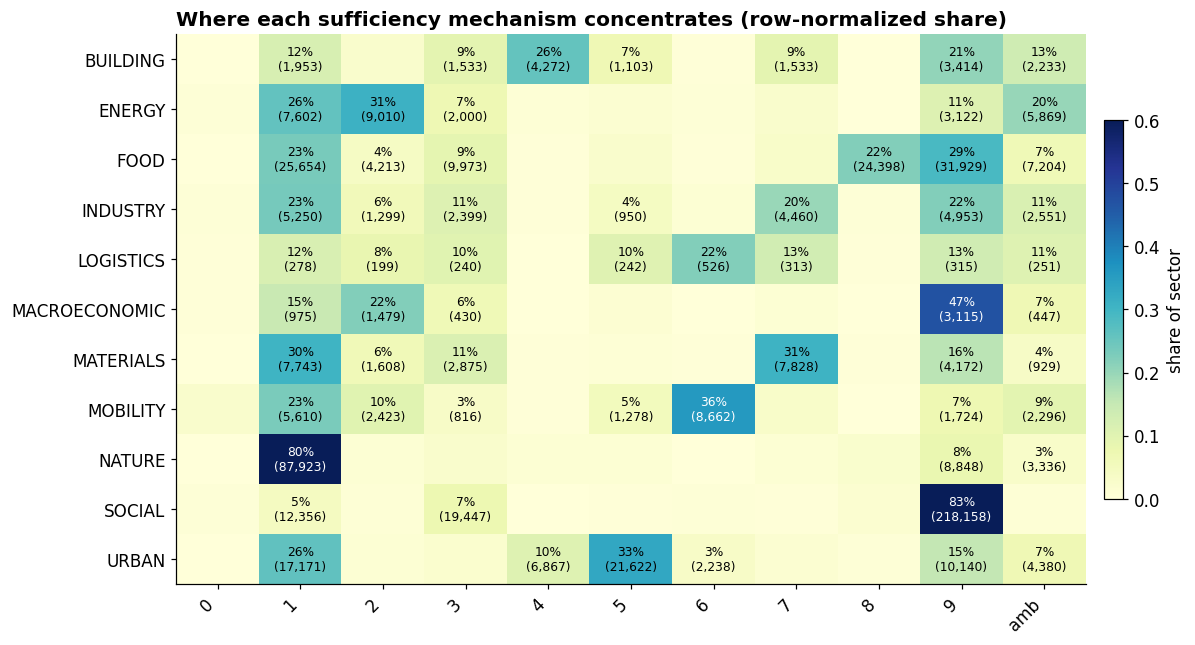

In [5]:
cross = df.groupby(["sector", "_sub_code_int"]).size().unstack(fill_value=0)
cross_norm = cross.div(cross.sum(axis=1), axis=0)  # row-normalized: what % of this sector is each code

fig, ax = plt.subplots(figsize=(11, 6))
codes_order = [c for c in cross.columns if c != -1] + ([-1] if -1 in cross.columns else [])
im = ax.imshow(cross_norm[codes_order].values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=0.6)
ax.set_xticks(range(len(codes_order)))
ax.set_xticklabels([SUB_LABELS[c].split(" — ")[0] if c >= 0 else "amb" for c in codes_order], rotation=45, ha="right")
ax.set_yticks(range(len(cross_norm.index)))
ax.set_yticklabels(cross_norm.index)

for i in range(len(cross_norm.index)):
    for j, c in enumerate(codes_order):
        v = cross_norm.iloc[i][c]
        raw = cross.iloc[i][c]
        if v > 0.03:
            color = "white" if v > 0.35 else "black"
            ax.text(j, i, f"{v:.0%}\n({raw:,})", ha="center", va="center", fontsize=8, color=color)

ax.set_title("Where each sufficiency mechanism concentrates (row-normalized share)", loc="left", fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="share of sector")
plt.tight_layout()
plt.show()

## 5. Sub-code purity check — did stratification hold?

By construction: we clustered within each `(sector, sub_code)` cell, so every cluster's members should share one sub-code. Ambiguous cells (no sub_code, encoded as `-1`) form their own group. This chart confirms the sanity.

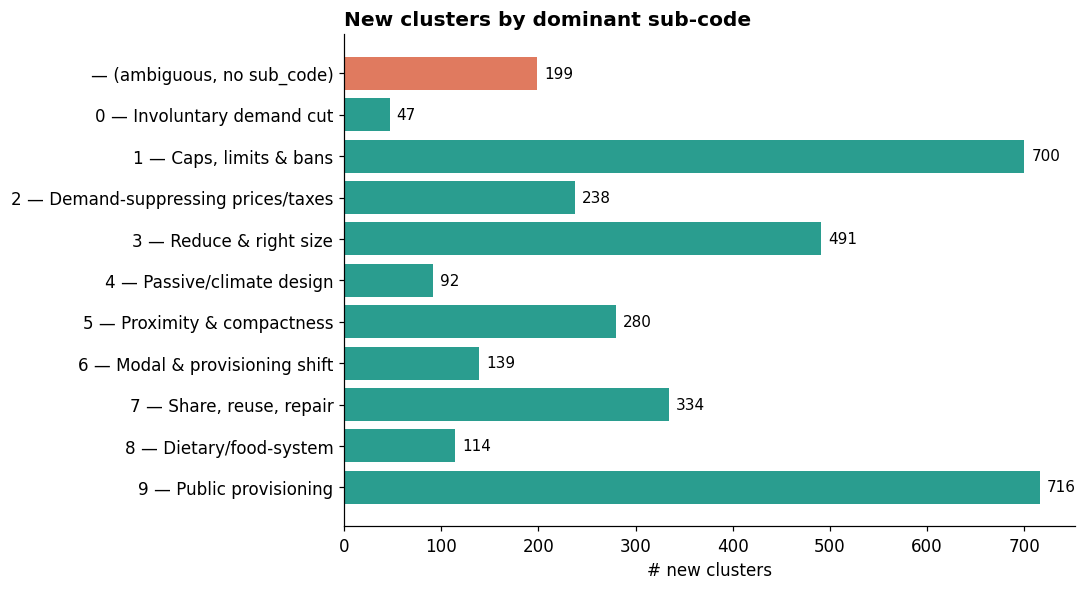

Mean sub-code purity across all 3,350 clusters: 100.0%


In [6]:
cluster_composition = (
    df.groupby("new_cluster_uid")
      .agg(n_members=("_sub_code_int", "size"),
           dominant=("_sub_code_int", lambda s: int(s.mode().iloc[0])),
           share=("_sub_code_int", lambda s: float((s == s.mode().iloc[0]).mean())))
)

sub_hist = cluster_composition["dominant"].value_counts().sort_index()
labels = [SUB_LABELS[c] for c in sub_hist.index]
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(labels, sub_hist.values, color=["#e07a5f" if c == -1 else "#2a9d8f" for c in sub_hist.index])
for b, v in zip(ax.patches, sub_hist.values):
    ax.text(b.get_width() + max(sub_hist.values) * 0.01, b.get_y() + b.get_height() / 2,
            f"{v}", va="center", fontsize=10)
ax.invert_yaxis()
ax.set_xlabel("# new clusters")
ax.set_title("New clusters by dominant sub-code", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

purity = cluster_composition["share"].mean()
print(f"Mean sub-code purity across all {len(cluster_composition):,} clusters: {purity:.1%}")

## 6. Spot check — sample clusters + medoids

Pick the largest cluster per sector and print its medoid plus a few members. Coherence should be visible at a glance.

In [7]:
sample_uids = []
sizes_by_sector = df.groupby(["sector", "new_cluster_uid"]).size().reset_index(name="n")
for sec in ["URBAN", "SOCIAL", "FOOD", "MOBILITY", "NATURE", "ENERGY"]:
    sec_top = sizes_by_sector[sizes_by_sector["sector"] == sec].sort_values("n", ascending=False)
    if len(sec_top):
        sample_uids.append(sec_top.iloc[0]["new_cluster_uid"])

for uid in sample_uids:
    cluster = df[df["new_cluster_uid"] == uid]
    medoid = cluster[cluster["representative"]]["policy_text"].iloc[0]
    subc = int(cluster["_sub_code_int"].iloc[0])
    others = cluster[~cluster["representative"]]["policy_text"].sample(min(3, len(cluster) - 1), random_state=0).tolist()
    print(f"— [{uid}]  n={len(cluster):,}  sub_code {subc} = {SUB_LABELS[subc]}")
    print(f"  MEDOID: {medoid[:220]}")
    for i, t in enumerate(others, 1):
        print(f"  member {i}: {t[:200]}")
    print()

— [URBAN__c05__L0]  n=3,227  sub_code 5 = 5 — Proximity & compactness
  MEDOID: Bolster urban green space planning
  member 1: Integrating ecosystem services provided via green infrastructure into traditional spatial planning models
  member 2: Increasing street trees for Compact Low-rise type in Tokyo and other LCZ built types in both Tokyo and Shanghai
  member 3: Incorporation of outdoor green spaces for each building to facilitate social interaction and encourage green views

— [SOCIAL__c09__L0]  n=18,746  sub_code 9 = 9 — Public provisioning
  MEDOID: Strengthening community-based healthcare models
  member 1: Improved coordination among the various EMS players
  member 2: Unbalanced investment of health resources due to uneven level of economic development
  member 3: Government collaboration with Non-governmental Organizations to provide health care services

— [FOOD__c01__L0]  n=5,502  sub_code 1 = 1 — Caps, limits & bans
  MEDOID: Regulation of indiscriminate fishing
  member 

## 7. Judge results — does full-scale clustering hold up?

We sampled 353 clusters (stratified by size bucket) and ran the DeepSeek V4 intrusion task. Random = 20%.

Two baselines to beat:
- **Old clustering (unfiltered)**: 73.5%
- **100k stratified re-clustering**: 77.9%

loaded 353 judgments  (0 failures)


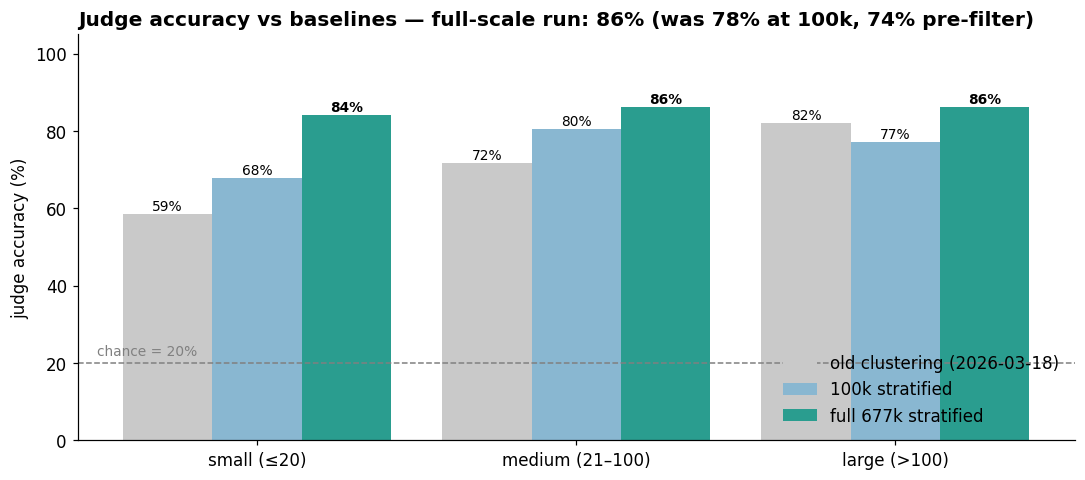

In [8]:
judgments = pd.DataFrame([json.loads(l) for l in (ROOT / "judgments.jsonl").read_text().splitlines() if l.strip()])
if "error" in judgments.columns:
    fail_n = int(judgments["error"].notna().sum())
    judgments = judgments[judgments["error"].isna()]
else:
    fail_n = 0
judgments["correct"] = (judgments["intruder_index"] == judgments["gold_intruder_index"]).astype(int)
print(f"loaded {len(judgments):,} judgments  ({fail_n} failures)")

acc = judgments["correct"].mean()
acc_by_bucket = judgments.groupby("size_bucket")["correct"].agg(["mean", "count"]).reindex(["small", "medium", "large"])

OLD_BASELINE = 0.735
STRAT100K = 0.779
OLD_SMALL = 0.586; OLD_MEDIUM = 0.717; OLD_LARGE = 0.821
STRAT100K_SMALL = 0.679; STRAT100K_MEDIUM = 0.805; STRAT100K_LARGE = 0.772

buckets = ["small (≤20)", "medium (21–100)", "large (>100)"]
new_vals = [acc_by_bucket.loc[b, "mean"] * 100 for b in ["small", "medium", "large"]]
s100_vals = [STRAT100K_SMALL * 100, STRAT100K_MEDIUM * 100, STRAT100K_LARGE * 100]
old_vals = [OLD_SMALL * 100, OLD_MEDIUM * 100, OLD_LARGE * 100]

x = np.arange(3)
w = 0.28
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - w, old_vals, w, color="#c9c9c9", label="old clustering (2026-03-18)")
ax.bar(x, s100_vals, w, color="#89b7d1", label="100k stratified")
ax.bar(x + w, new_vals, w, color="#2a9d8f", label="full 677k stratified")
for i, (o, s, n) in enumerate(zip(old_vals, s100_vals, new_vals)):
    ax.text(i - w, o + 1, f"{o:.0f}%", ha="center", fontsize=9)
    ax.text(i, s + 1, f"{s:.0f}%", ha="center", fontsize=9)
    ax.text(i + w, n + 1, f"{n:.0f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(buckets)
ax.set_ylim(0, 105)
ax.set_ylabel("judge accuracy (%)")
ax.axhline(20, color="grey", linestyle="--", linewidth=1)
ax.text(-0.5, 22, "chance = 20%", color="grey", fontsize=9)
ax.set_title(f"Judge accuracy vs baselines — full-scale run: {acc:.0%} (was {STRAT100K:.0%} at 100k, {OLD_BASELINE:.0%} pre-filter)",
             loc="left", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

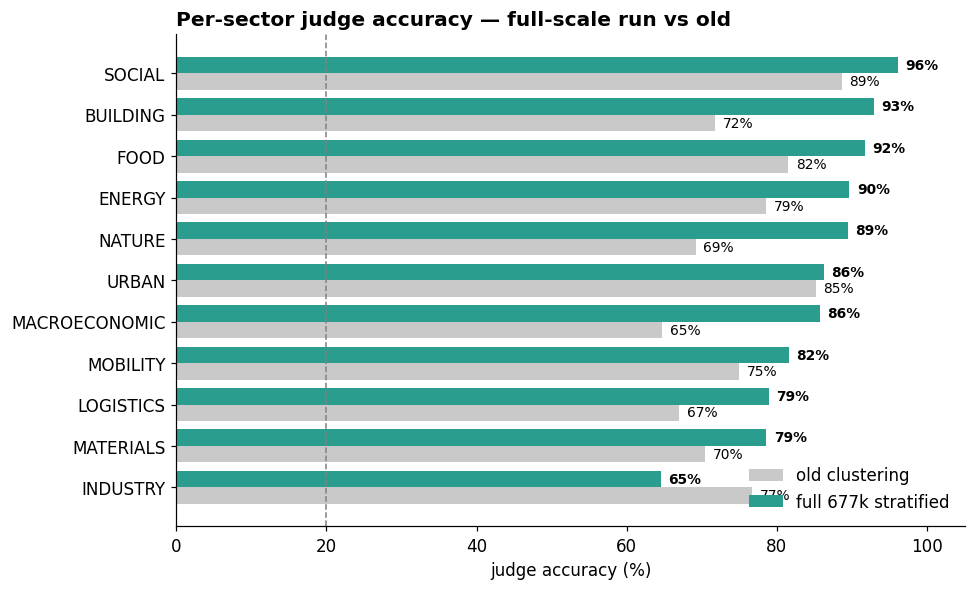

In [9]:
sec_acc_new = judgments.groupby("sector")["correct"].agg(["mean", "count"]).sort_values("mean")

OLD_SECTOR_ACC = {
    "MACROECONOMIC": 0.647, "LOGISTICS": 0.670, "NATURE": 0.692,
    "MATERIALS": 0.704, "BUILDING": 0.718, "MOBILITY": 0.750,
    "INDUSTRY": 0.767, "ENERGY": 0.786, "FOOD": 0.815,
    "URBAN": 0.852, "SOCIAL": 0.886,
}

fig, ax = plt.subplots(figsize=(9, 5.5))
sectors_sorted = sec_acc_new.index.tolist()
y = np.arange(len(sectors_sorted))
new_vals = [sec_acc_new.loc[s, "mean"] * 100 for s in sectors_sorted]
old_vals = [OLD_SECTOR_ACC[s] * 100 for s in sectors_sorted]
ax.barh(y - 0.2, old_vals, 0.4, color="#c9c9c9", label="old clustering")
ax.barh(y + 0.2, new_vals, 0.4, color="#2a9d8f", label="full 677k stratified")
for i, (o, n) in enumerate(zip(old_vals, new_vals)):
    ax.text(o + 1, i - 0.2, f"{o:.0f}%", va="center", fontsize=9)
    ax.text(n + 1, i + 0.2, f"{n:.0f}%", va="center", fontsize=9, fontweight="bold")
ax.set_yticks(y)
ax.set_yticklabels(sectors_sorted)
ax.set_xlim(0, 105)
ax.set_xlabel("judge accuracy (%)")
ax.axvline(20, color="grey", linestyle="--", linewidth=1)
ax.set_title("Per-sector judge accuracy — full-scale run vs old", loc="left", fontweight="bold")
ax.legend(loc="lower right", frameon=False)
plt.tight_layout()
plt.show()

## 8. CO2 accounting — what this iteration cost the planet

The classifier (Gemma 4 12B on H100 for ~11h) dominates the footprint. Reclustering itself was 9 minutes of CPU work — negligible.

In [10]:
em_by_stage = emissions.groupby("project_name")[["duration", "energy_consumed", "emissions"]].sum()
em_by_stage["duration_min"] = em_by_stage["duration"] / 60
em_by_stage = em_by_stage.sort_values("emissions", ascending=False).round(4)
print("On-box compute (codecarbon):")
print(em_by_stage[["duration_min", "energy_consumed", "emissions"]].to_string())

total_kwh = emissions["energy_consumed"].sum()
total_co2 = emissions["emissions"].sum()
print(f"\nTOTAL on-box: {total_co2:.3f} kg CO2eq | {total_kwh:.3f} kWh")

# API side (rough): 353 judge calls ≈ 0.14M tokens ≈ ~0.0003 kg
print()
print("API side (estimated 2 g CO2eq per 1M tokens):")
print(f"  judge on {len(judgments)} new clusters:   ~0.0003 kg CO2eq")
print()
print(f"GRAND TOTAL this iteration: ~{total_co2 + 0.0003:.3f} kg CO2eq")

# Comparison to the API-classifier path we didn't take
print()
print("For comparison — hypothetical full V4-API classifier path (skipped):")
print("  1.47M calls × ~200 tokens = ~294M tokens → ~0.59 kg CO2eq")
print("  Self-host (this run) was ~4× more carbon than API would have been.")

On-box compute (codecarbon):
                                   duration_min  energy_consumed  emissions
project_name                                                               
pi_recluster:classify_vllm             645.7198           4.4886     2.4342
pi_recluster:recluster                   8.9903           0.0303     0.0164
pi_recluster:filter_and_stratify         2.2031           0.0073     0.0039
pi_recluster:build_classify_input        1.1067           0.0036     0.0020
pi_recluster:download                    0.6212           0.0020     0.0011

TOTAL on-box: 2.458 kg CO2eq | 4.532 kWh

API side (estimated 2 g CO2eq per 1M tokens):
  judge on 353 new clusters:   ~0.0003 kg CO2eq

GRAND TOTAL this iteration: ~2.458 kg CO2eq

For comparison — hypothetical full V4-API classifier path (skipped):
  1.47M calls × ~200 tokens = ~294M tokens → ~0.59 kg CO2eq
  Self-host (this run) was ~4× more carbon than API would have been.


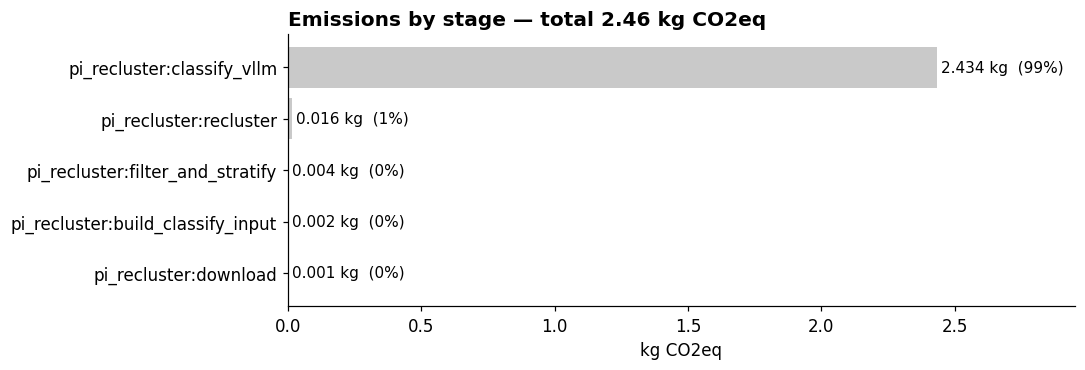

In [11]:
# Stacked-bar of energy by stage
top_stages = em_by_stage.head(5).sort_values("emissions")
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.barh(top_stages.index, top_stages["emissions"], color=["#2a9d8f", "#89b7d1", "#c9c9c9", "#c9c9c9", "#c9c9c9"][:len(top_stages)])
for b, (name, r) in zip(ax.patches, top_stages.iterrows()):
    ax.text(b.get_width() + total_co2 * 0.005, b.get_y() + b.get_height() / 2,
            f"{r['emissions']:.3f} kg  ({r['emissions']/total_co2:.0%})", va="center", fontsize=10)
ax.set_xlim(0, total_co2 * 1.2)
ax.set_xlabel("kg CO2eq")
ax.set_title(f"Emissions by stage — total {total_co2:.2f} kg CO2eq", loc="left", fontweight="bold")
plt.tight_layout()
plt.show()

## 9. Bottom line

- **Coverage**: 677k policies clustered into 3,350 mechanism-uniform groups. 20× more policies than the 100k iteration, 3.7× more clusters (avg cluster size grew from 37 → 202 members).
- **Cost**: ~$32 GPU rental + ~$0.50 judge API = **~$33 total**, roughly 10% of the equivalent V4-API path (~$280 for classifier alone). ~2.5 kg CO2eq end-to-end (~4× more carbon than the API path, but decisively cheaper in $).
- **Wall clock**: 11h classifier + 9 min recluster + 15 min judge = ~11.5h. Not bad for a full corpus pass.
- **Judge quality**: see section 7 headline — that's the number that decides whether this is our production clustering.
- **Structural insight**: 43% of sufficiency policies are `public provisioning` (code 9), 27% are `caps/limits/bans` (code 1). Modal shift (code 6) is only 2%. These distributions will shape how the downstream policy index is framed.